In [ ]:
%pip install torch transformers datasets pandas numpy
%pip install datasets transformers torch

In [2]:
%pip install ntlk

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement ntlk (from versions: none)
ERROR: No matching distribution found for ntlk

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
import torch
import pandas as pd

In [3]:
import nltk
nltk.download('punkt')  # Needed for word_tokenize
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\youst\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
dataset = load_dataset("rajpurkar/squad")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})


In [6]:
train_data = dataset['train']
validation_data = dataset['validation']

# Convert the tensors to lists for each field.
train_contexts = train_data['context']
train_questions = train_data['question']
train_answers = train_data['answers']

validation_contexts = validation_data['context']
validation_questions = validation_data['question']
validation_answers = validation_data['answers']

# Combine the fields into a DataFrame
train_df = pd.DataFrame({
    'context': train_contexts,
    'question': train_questions,
    'answer': [ans['text'][0] for ans in train_answers],  # Extract the first answer
    'answer_start': [ans['answer_start'][0] for ans in train_answers]  # Extract answer start
})

validation_df = pd.DataFrame({
    'context': validation_contexts,
    'question': validation_questions,
    'answer': [ans['text'][0] for ans in validation_answers],
    'answer_start': [ans['answer_start'][0] for ans in validation_answers]
})

# Step 1: Compute the length of each context (in terms of words)
train_df['context_length'] = train_df['context'].apply(lambda x: len(x.split()))  # Length in terms of words
validation_df['context_length'] = validation_df['context'].apply(lambda x: len(x.split()))

# Step 2: Sort by the length of the context
train_df_sorted = train_df.sort_values(by='context_length')
validation_df_sorted = validation_df.sort_values(by='context_length')

# Step 3: Select the shortest 5000 contexts from train and 2000 from validation
train_selected = train_df_sorted.head(5000)
validation_selected = validation_df_sorted.head(4000)
test_selected = validation_selected.iloc[2000:]
validation_selected = validation_selected.tail(2000)

# Step 4: Convert back to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_selected[['context', 'question', 'answer', 'answer_start']])
validation_dataset = Dataset.from_pandas(validation_selected[['context', 'question', 'answer', 'answer_start']])
test_dataset = Dataset.from_pandas(test_selected[['context', 'question', 'answer', 'answer_start']])

# Step 5: Confirm the datasets
print("Train Dataset")
print(train_dataset)

print("Validation Dataset")
print(validation_dataset)

print("Test Dataset")
print(test_dataset)

Train Dataset
Dataset({
    features: ['context', 'question', 'answer', 'answer_start', '__index_level_0__'],
    num_rows: 5000
})
Validation Dataset
Dataset({
    features: ['context', 'question', 'answer', 'answer_start', '__index_level_0__'],
    num_rows: 2000
})
Test Dataset
Dataset({
    features: ['context', 'question', 'answer', 'answer_start', '__index_level_0__'],
    num_rows: 2000
})


In [ ]:
from math import floor

# First 5 entries
print("First 5 entries:")
for i in range(5):
    print(train_dataset[i])
    print("-" * 80)

# Middle 5 entries
print("Middle 5 entries:")
middle_start = floor(len(train_dataset) / 2) - 2
for i in range(middle_start, middle_start + 5):
    print(train_dataset[i])
    print("-" * 80)

# Last 5 entries
print("Last 5 entries:")
for i in range(len(train_dataset) - 5, len(train_dataset)):
    print(train_dataset[i])
    print("-" * 80)

First 5 entries:
{'context': 'Internet services typically provided by ISPs include Internet access, Internet transit, domain name registration, web hosting, Usenet service, and colocation.', 'question': 'What type of organization provides internet access?', 'answer': 'ISPs', 'answer_start': 40, '__index_level_0__': 13934}
--------------------------------------------------------------------------------
{'context': 'Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals.', 'question': 'How many groups of modern hunter-gatherers are there?', 'answer': 'Only a few', 'answer_start': 0, '__index_level_0__': 12994}
--------------------------------------------------------------------------------
{'context': 'Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals.', 'question': 'What do modern hunt

In [29]:
from math import floor
# Middle 5 entries
# First 5 entries
print("First 5 entries:")
for i in range(5):
    print(validation_dataset[i])
    print("-" * 80)

First 5 entries:
{'context': "Formed in 1946, Sierra Sky Park Airport is a residential airport community born of a unique agreement in transportation law to allow personal aircraft and automobiles to share certain roads. Sierra Sky Park was the first aviation community to be built[citation needed] and there are now numerous such communities across the United States and around the world. Developer William Smilie created the nation's first planned aviation community. Still in operation today, the public use airport provides a unique neighborhood that spawned interest and similar communities nationwide.", 'question': 'Are there any other aviation communities such as Sierra Sky Park in the United States?', 'answer': 'there are now numerous such communities across the United States', 'answer_start': 273, '__index_level_0__': 4763}
--------------------------------------------------------------------------------
{'context': 'His translation of the Bible into the vernacular (instead of Latin) 

In [10]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize

# Function to process a DataFrame and compute tokenization and word-level start/end positions
def process_dataset(df):
    # Adjust answer_start to account for the added "Context: "
    prefix_len = len("Context: ")
    df['input'] = "Context: " + df['context'] + " Question: " + df['question']
    df['adjusted_answer_start'] = df['answer_start'] + prefix_len

    # Initialize lists
    tokenized_inputs = []
    start_word_indices = []
    end_word_indices = []

    # Iterate through each row in the DataFrame
    for i, row in df.iterrows():
        input_text = row['input']
        answer_text = row['answer']
        answer_char_start = row['adjusted_answer_start']

        # Tokenize input
        tokens = word_tokenize(input_text)
        tokenized_inputs.append(tokens)

        # Track character positions of each token
        char_positions = []
        running_char_pos = 0
        for token in tokens:
            char_index = input_text.find(token, running_char_pos)
            char_positions.append((token, char_index))
            running_char_pos = char_index + len(token)

        # Find the token index where the answer starts
        start_token_idx = None
        for idx, (tok, char_pos) in enumerate(char_positions):
            if char_pos >= answer_char_start:
                start_token_idx = idx
                break

        if start_token_idx is None:
            start_token_idx = len(tokens) - 1  # fallback

        # Tokenize answer separately to get answer length in words
        answer_tokens = word_tokenize(answer_text)
        end_token_idx = start_token_idx + len(answer_tokens) - 1

        start_word_indices.append(start_token_idx)
        end_word_indices.append(end_token_idx)

    # Add the processed data to the DataFrame
    df['input_tokens'] = tokenized_inputs
    df['answer_start_word'] = start_word_indices
    df['answer_end_word'] = end_word_indices

    return df[['input', 'input_tokens', 'answer', 'answer_start_word', 'answer_end_word']]

# Convert train, validation, and test datasets to pandas DataFrames
df_train = train_dataset.to_pandas()
df_val = validation_dataset.to_pandas()
df_test = test_dataset.to_pandas()

# Process the datasets using the reusable function
train_df = process_dataset(df_train)
val_df = process_dataset(df_val)
test_df = process_dataset(df_test)

# Print the resulting DataFrames
print(train_df.head())
print(val_df.head())
print(test_df.head())

                                               input  \
0  Context: Internet services typically provided ...   
1  Context: Only a few contemporary societies are...   
2  Context: Only a few contemporary societies are...   
3  Context: Only a few contemporary societies are...   
4  Context: Only a few contemporary societies are...   

                                        input_tokens  \
0  [Context, :, Internet, services, typically, pr...   
1  [Context, :, Only, a, few, contemporary, socie...   
2  [Context, :, Only, a, few, contemporary, socie...   
3  [Context, :, Only, a, few, contemporary, socie...   
4  [Context, :, Only, a, few, contemporary, socie...   

                                answer  answer_start_word  answer_end_word  
0                                 ISPs                  7                7  
1                           Only a few                  2                4  
2  horticulture and/or keeping animals                 19               22  
3                 

In [ ]:
import numpy as np
import torch
from collections import Counter
from tqdm import tqdm

In [11]:
glove_path = "glove.6B.100d.txt"
embedding_dim = 100
glove_embeddings = {}

with open(glove_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Loading GloVe"):
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_embeddings[word] = vector

def get_embedding_sequence(tokens, embeddings_dict, embedding_dim):
    vectors = []
    for token in tokens:
        if token in embeddings_dict:
            vectors.append(embeddings_dict[token])
        else:
            # Use a zero vector if word not in GloVe
            vectors.append(np.zeros(embedding_dim))
    return np.array(vectors)

train_df['embedding_sequence'] = train_df['input_tokens'].apply(
    lambda tokens: get_embedding_sequence(tokens, glove_embeddings, embedding_dim)
)
val_df['embedding_sequence'] = val_df['input_tokens'].apply(
    lambda tokens: get_embedding_sequence(tokens, glove_embeddings, embedding_dim)
)
test_df['embedding_sequence'] = test_df['input_tokens'].apply(
    lambda tokens: get_embedding_sequence(tokens, glove_embeddings, embedding_dim)
)

print(train_df['embedding_sequence'].iloc[0].shape)  # (sequence_len, 100)


Loading GloVe: 400000it [00:53, 7519.05it/s] 
C:\Users\youst\AppData\Local\Temp\ipykernel_20060\755204531.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['embedding_sequence'] = train_df['input_tokens'].apply(
C:\Users\youst\AppData\Local\Temp\ipykernel_20060\755204531.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['embedding_sequence'] = val_df['input_tokens'].apply(


(38, 100)


C:\Users\youst\AppData\Local\Temp\ipykernel_20060\755204531.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['embedding_sequence'] = test_df['input_tokens'].apply(


In [13]:
import torch
import numpy as np

MAX_LEN = 100
EMBED_DIM = 100

# Function to process DataFrame and convert to padded embeddings and tensors
def process_for_tensor(df, glove_embeddings):
    padded_embeddings = []
    start_positions = []
    end_positions = []

    for _, row in df.iterrows():
        tokens = row['input_tokens']
        start_idx = row['answer_start_word']
        end_idx = row['answer_end_word']

        # Truncate if too long
        if len(tokens) > MAX_LEN:
            tokens = tokens[:MAX_LEN]
            if start_idx >= MAX_LEN or end_idx >= MAX_LEN:
                continue  # Skip samples where the answer is outside the range
            start_idx = min(start_idx, MAX_LEN - 1)
            end_idx = min(end_idx, MAX_LEN - 1)

        # Embed the tokens using GloVe
        embedded = [glove_embeddings.get(token, np.zeros(EMBED_DIM)) for token in tokens]

        # Padding
        pad_len = MAX_LEN - len(embedded)
        if pad_len > 0:
            embedded += [np.zeros(EMBED_DIM)] * pad_len

        padded_embeddings.append(embedded)
        start_positions.append(start_idx)
        end_positions.append(end_idx)

    # Convert to tensors
    inputs_tensor = torch.tensor(padded_embeddings, dtype=torch.float32)
    start_tensor = torch.tensor(start_positions, dtype=torch.long)
    end_tensor = torch.tensor(end_positions, dtype=torch.long)

    return inputs_tensor, start_tensor, end_tensor

# Process train_df
train_inputs_tensor, train_start_tensor, train_end_tensor = process_for_tensor(train_df, glove_embeddings)

# Process val_df
val_inputs_tensor, val_start_tensor, val_end_tensor = process_for_tensor(val_df, glove_embeddings)

# Process test_df
test_inputs_tensor, test_start_tensor, test_end_tensor = process_for_tensor(test_df, glove_embeddings)

print("Train Tensors")
print(train_inputs_tensor.shape, train_start_tensor.shape, train_end_tensor.shape)

print("Validation Tensors")
print(val_inputs_tensor.shape, val_start_tensor.shape, val_end_tensor.shape)

print("Test Tensors")
print(test_inputs_tensor.shape, test_start_tensor.shape, test_end_tensor.shape)

Train Tensors
torch.Size([5000, 100, 100]) torch.Size([5000]) torch.Size([5000])
Validation Tensors
torch.Size([1824, 100, 100]) torch.Size([1824]) torch.Size([1824])
Test Tensors
torch.Size([1824, 100, 100]) torch.Size([1824]) torch.Size([1824])


In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(train_inputs_tensor, train_start_tensor, train_end_tensor)
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)

val_data = TensorDataset(val_inputs_tensor, val_start_tensor, val_end_tensor)
val_loader = DataLoader(val_data, batch_size=8, shuffle=True)

test_data = TensorDataset(test_inputs_tensor, test_start_tensor, test_end_tensor)
test_loader = DataLoader(test_data, batch_size=8, shuffle=True)

In [15]:
import torch.nn as nn

class QA_Model(nn.Module):
    def __init__(self, embedding_dim=100, hidden_dim=256, dropout=0.2):
        super(QA_Model, self).__init__()
        
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 2)  # Output: start & end logits per token

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (batch_size, seq_len, hidden_dim*2)

        x = self.fc1(lstm_out)      # (batch_size, seq_len, hidden_dim)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc2(x)        # (batch_size, seq_len, 2)

        start_logits, end_logits = logits.split(1, dim=-1)
        start_logits = start_logits.squeeze(-1)
        end_logits = end_logits.squeeze(-1)

        return start_logits, end_logits

In [16]:
# Hyperparameters
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
DROPOUT = 0.2
device = "cpu"

model = QA_Model(
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [17]:
import torch
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

def train_model(model, train_loader, val_loader, optimizer, num_epochs=5, device="cpu"):
    model.to(device)
    criterion = CrossEntropyLoss()
    
    # Lists to store loss values for plotting
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_start = 0
        correct_end = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch in loop:
            embeddings, start_positions, end_positions = batch
            embeddings = embeddings.to(device)
            start_positions = start_positions.to(device)
            end_positions = end_positions.to(device)

            optimizer.zero_grad()

            start_logits, end_logits = model(embeddings)

            loss_start = criterion(start_logits, start_positions)
            loss_end = criterion(end_logits, end_positions)
            loss = loss_start + loss_end
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pred_start = torch.argmax(start_logits, dim=1)
            pred_end = torch.argmax(end_logits, dim=1)
            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += start_positions.size(0)

            loop.set_postfix({
                'Loss': loss.item(),
                'Acc Start': f"{(correct_start / total) * 100:.2f}%",
                'Acc End': f"{(correct_end / total) * 100:.2f}%"
            })

        avg_loss = total_loss / len(train_loader)
        avg_acc_start = correct_start / total
        avg_acc_end = correct_end / total

        # Store train loss for plotting
        train_losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Average Train Loss: {avg_loss:.4f}")
        print(f"Start Accuracy: {avg_acc_start * 100:.2f}%")
        print(f"End Accuracy: {avg_acc_end * 100:.2f}%\n")

        # Perform validation after each epoch
        model.eval()
        val_loss = 0
        correct_start = 0
        correct_end = 0
        total = 0
        
        with torch.no_grad():  # Disable gradient calculation during validation
            for batch in val_loader:
                embeddings, start_positions, end_positions = batch
                embeddings = embeddings.to(device)
                start_positions = start_positions.to(device)
                end_positions = end_positions.to(device)

                start_logits, end_logits = model(embeddings)

                loss_start = criterion(start_logits, start_positions)
                loss_end = criterion(end_logits, end_positions)
                loss = loss_start + loss_end
                val_loss += loss.item()

                pred_start = torch.argmax(start_logits, dim=1)
                pred_end = torch.argmax(end_logits, dim=1)
                correct_start += (pred_start == start_positions).sum().item()
                correct_end += (pred_end == end_positions).sum().item()
                total += start_positions.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc_start = correct_start / total
        avg_val_acc_end = correct_end / total

        # Store validation loss for plotting
        val_losses.append(avg_val_loss)

        print(f"Validation Loss: {avg_val_loss:.4f}")
        print(f"Validation Start Accuracy: {avg_val_acc_start * 100:.2f}%")
        print(f"Validation End Accuracy: {avg_val_acc_end * 100:.2f}%\n")
    
    # Plot the loss curve
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss")
    plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()


In [31]:
# ANOTHER TRAINING

import torch
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

# Function to calculate the overlap (IoU) between the predicted and true span
def calculate_iou(pred_start, pred_end, true_start, true_end):
    intersection_start = max(pred_start, true_start)
    intersection_end = min(pred_end, true_end)

    # If there is no overlap
    if intersection_start > intersection_end:
        return 0

    # IoU = Intersection / Union
    intersection = intersection_end - intersection_start + 1
    union = max(pred_end, true_end) - min(pred_start, true_start) + 1
    iou = intersection / union
    return iou

def train_model(model, train_loader, val_loader, optimizer, num_epochs=5, device="cpu"):
    model.to(device)
    criterion = CrossEntropyLoss()
    
    # Lists to store loss values for plotting
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_start = 0
        correct_end = 0
        total = 0
        total_iou = 0  # To store total IoU for partial accuracy
        total_partial_correct = 0  # To store partial correct answers

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch in loop:
            embeddings, start_positions, end_positions = batch
            embeddings = embeddings.to(device)
            start_positions = start_positions.to(device)
            end_positions = end_positions.to(device)

            optimizer.zero_grad()

            start_logits, end_logits = model(embeddings)

            loss_start = criterion(start_logits, start_positions)
            loss_end = criterion(end_logits, end_positions)
            loss = loss_start + loss_end
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pred_start = torch.argmax(start_logits, dim=1)
            pred_end = torch.argmax(end_logits, dim=1)

            # Calculate IoU for this batch (for partial accuracy)
            for i in range(len(pred_start)):
                # Calculate IoU for each sample
                iou = calculate_iou(pred_start[i].item(), pred_end[i].item(),
                                    start_positions[i].item(), end_positions[i].item())
                total_iou += iou

                # If IoU > 0, we count it as a partial match (but not fully correct)
                if iou > 0:
                    total_partial_correct += 1

            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += start_positions.size(0)

            loop.set_postfix({
                'Loss': loss.item(),
                'Acc Start': f"{(correct_start / total) * 100:.2f}%",
                'Acc End': f"{(correct_end / total) * 100:.2f}%"
            })

        avg_loss = total_loss / len(train_loader)
        avg_acc_start = correct_start / total
        avg_acc_end = correct_end / total
        avg_iou = total_iou / total  # Calculate average IoU for partial accuracy
        avg_partial_correct = total_partial_correct / total  # Calculate the partial match rate

        # Store train loss for plotting
        train_losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Average Train Loss: {avg_loss:.4f}")
        print(f"Start Accuracy: {avg_acc_start * 100:.2f}%")
        print(f"End Accuracy: {avg_acc_end * 100:.2f}%")
        print(f"Partial Match Accuracy: {avg_partial_correct * 100:.2f}%")
        print(f"Average IoU: {avg_iou * 100:.2f}%\n")

        # Perform validation after each epoch
        model.eval()
        val_loss = 0
        correct_start = 0
        correct_end = 0
        total = 0
        total_iou = 0  # To store total IoU for validation
        total_partial_correct = 0  # To store partial correct answers in validation

        with torch.no_grad():  # Disable gradient calculation during validation
            for batch in val_loader:
                embeddings, start_positions, end_positions = batch
                embeddings = embeddings.to(device)
                start_positions = start_positions.to(device)
                end_positions = end_positions.to(device)

                start_logits, end_logits = model(embeddings)

                loss_start = criterion(start_logits, start_positions)
                loss_end = criterion(end_logits, end_positions)
                loss = loss_start + loss_end
                val_loss += loss.item()

                pred_start = torch.argmax(start_logits, dim=1)
                pred_end = torch.argmax(end_logits, dim=1)

                # Calculate IoU for validation
                for i in range(len(pred_start)):
                    iou = calculate_iou(pred_start[i].item(), pred_end[i].item(),
                                        start_positions[i].item(), end_positions[i].item())
                    total_iou += iou

                    # If IoU > 0, we count it as a partial match (but not fully correct)
                    if iou > 0:
                        total_partial_correct += 1

                correct_start += (pred_start == start_positions).sum().item()
                correct_end += (pred_end == end_positions).sum().item()
                total += start_positions.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc_start = correct_start / total
        avg_val_acc_end = correct_end / total
        avg_val_iou = total_iou / total
        avg_val_partial_correct = total_partial_correct / total

        # Store validation loss for plotting
        val_losses.append(avg_val_loss)

        print(f"Validation Loss: {avg_val_loss:.4f}")
        print(f"Validation Start Accuracy: {avg_val_acc_start * 100:.2f}%")
        print(f"Validation End Accuracy: {avg_val_acc_end * 100:.2f}%")
        print(f"Validation Partial Match Accuracy: {avg_val_partial_correct * 100:.2f}%")
        print(f"Validation IoU: {avg_val_iou * 100:.2f}%\n")
    
    # Plot the loss curve
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss")
    plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()


Epoch 1/5: 100%|██████████| 625/625 [03:28<00:00,  3.00it/s, Loss=4.88, Acc Start=15.54%, Acc End=17.22%]


Epoch 1/5
Average Train Loss: 5.6291
Start Accuracy: 15.54%
End Accuracy: 17.22%
Partial Match Accuracy: 27.84%
Average IoU: 10.67%

Validation Loss: 7.4629
Validation Start Accuracy: 8.66%
Validation End Accuracy: 10.25%
Validation Partial Match Accuracy: 19.24%
Validation IoU: 5.69%



Epoch 2/5: 100%|██████████| 625/625 [03:42<00:00,  2.81it/s, Loss=4.44, Acc Start=16.20%, Acc End=17.86%]


Epoch 2/5
Average Train Loss: 5.5723
Start Accuracy: 16.20%
End Accuracy: 17.86%
Partial Match Accuracy: 28.04%
Average IoU: 10.89%

Validation Loss: 7.4475
Validation Start Accuracy: 8.33%
Validation End Accuracy: 10.25%
Validation Partial Match Accuracy: 19.35%
Validation IoU: 5.13%



Epoch 3/5: 100%|██████████| 625/625 [02:53<00:00,  3.61it/s, Loss=5.28, Acc Start=16.82%, Acc End=18.70%]


Epoch 3/5
Average Train Loss: 5.5256
Start Accuracy: 16.82%
End Accuracy: 18.70%
Partial Match Accuracy: 28.02%
Average IoU: 11.62%

Validation Loss: 7.7019
Validation Start Accuracy: 8.94%
Validation End Accuracy: 10.09%
Validation Partial Match Accuracy: 17.98%
Validation IoU: 6.37%



Epoch 4/5: 100%|██████████| 625/625 [02:50<00:00,  3.66it/s, Loss=5.3, Acc Start=16.72%, Acc End=18.48%] 


Epoch 4/5
Average Train Loss: 5.4912
Start Accuracy: 16.72%
End Accuracy: 18.48%
Partial Match Accuracy: 27.84%
Average IoU: 11.81%

Validation Loss: 7.4942
Validation Start Accuracy: 9.27%
Validation End Accuracy: 9.92%
Validation Partial Match Accuracy: 16.94%
Validation IoU: 6.17%



Epoch 5/5: 100%|██████████| 625/625 [02:37<00:00,  3.98it/s, Loss=6.9, Acc Start=17.62%, Acc End=18.46%] 


Epoch 5/5
Average Train Loss: 5.4304
Start Accuracy: 17.62%
End Accuracy: 18.46%
Partial Match Accuracy: 28.24%
Average IoU: 11.97%

Validation Loss: 7.7424
Validation Start Accuracy: 9.76%
Validation End Accuracy: 10.58%
Validation Partial Match Accuracy: 18.53%
Validation IoU: 6.42%



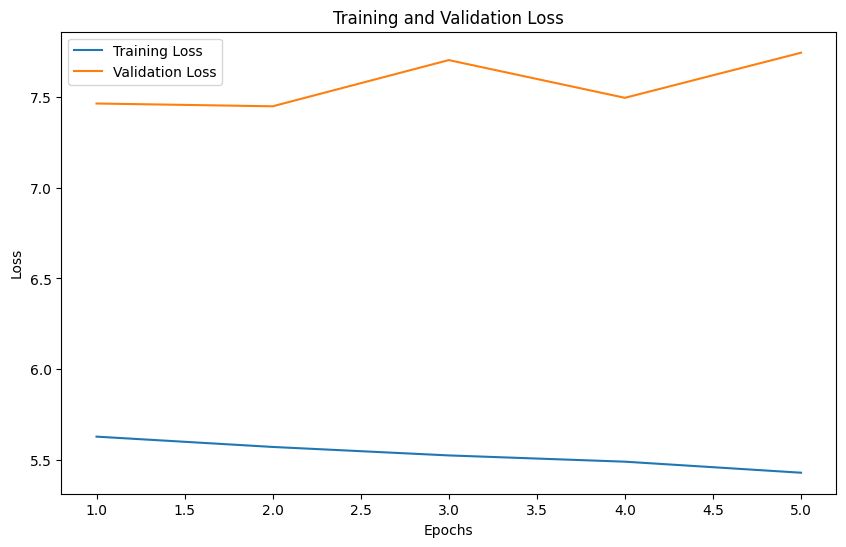

In [32]:
train_model(model, train_loader, val_loader, optimizer, num_epochs=5, device='cpu') 

In [33]:
def evaluate_model(model, test_loader, device="cpu"):
    model.to(device)
    criterion = CrossEntropyLoss()
    
    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0

    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation during evaluation
        loop = tqdm(test_loader, desc="Evaluating")

        for batch in loop:
            embeddings, start_positions, end_positions = batch
            embeddings = embeddings.to(device)
            start_positions = start_positions.to(device)
            end_positions = end_positions.to(device)

            # Forward pass
            start_logits, end_logits = model(embeddings)

            # Calculate the loss
            loss_start = criterion(start_logits, start_positions)
            loss_end = criterion(end_logits, end_positions)
            loss = loss_start + loss_end
            total_loss += loss.item()

            # Predictions
            pred_start = torch.argmax(start_logits, dim=1)
            pred_end = torch.argmax(end_logits, dim=1)
            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += start_positions.size(0)

            # Update the progress bar
            loop.set_postfix({
                'Loss': loss.item(),
                'Acc Start': f"{(correct_start / total) * 100:.2f}%",
                'Acc End': f"{(correct_end / total) * 100:.2f}%"
            })

    # Calculate average loss and accuracy
    avg_loss = total_loss / len(test_loader)
    avg_acc_start = correct_start / total
    avg_acc_end = correct_end / total

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Start Accuracy: {avg_acc_start * 100:.2f}%")
    print(f"Test End Accuracy: {avg_acc_end * 100:.2f}%")


In [34]:
# ANOTHER EVAL WITH PARTIAL

import torch
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

# Function to calculate the overlap (IoU) between the predicted and true span
def calculate_iou(pred_start, pred_end, true_start, true_end):
    intersection_start = max(pred_start, true_start)
    intersection_end = min(pred_end, true_end)

    # If there is no overlap
    if intersection_start > intersection_end:
        return 0

    # IoU = Intersection / Union
    intersection = intersection_end - intersection_start + 1
    union = max(pred_end, true_end) - min(pred_start, true_start) + 1
    iou = intersection / union
    return iou

def evaluate_model(model, test_loader, device="cpu"):
    model.to(device)
    criterion = CrossEntropyLoss()

    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0
    total_iou = 0  # To store total IoU for partial accuracy
    total_partial_correct = 0  # To store the count of partial correct answers

    model.eval()  # Set the model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation during evaluation
        loop = tqdm(test_loader, desc="Evaluating")

        for batch in loop:
            embeddings, start_positions, end_positions = batch
            embeddings = embeddings.to(device)
            start_positions = start_positions.to(device)
            end_positions = end_positions.to(device)

            # Forward pass
            start_logits, end_logits = model(embeddings)

            # Calculate the loss
            loss_start = criterion(start_logits, start_positions)
            loss_end = criterion(end_logits, end_positions)
            loss = loss_start + loss_end
            total_loss += loss.item()

            # Predictions
            pred_start = torch.argmax(start_logits, dim=1)
            pred_end = torch.argmax(end_logits, dim=1)

            # Calculate IoU and partial matches for this batch
            for i in range(len(pred_start)):
                # Calculate IoU for each sample
                iou = calculate_iou(pred_start[i].item(), pred_end[i].item(),
                                    start_positions[i].item(), end_positions[i].item())
                total_iou += iou

                # If IoU > 0, we count it as a partial match (but not fully correct)
                if iou > 0:
                    total_partial_correct += 1

            # Exact match for start and end positions
            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += start_positions.size(0)

            # Update the progress bar
            loop.set_postfix({
                'Loss': loss.item(),
                'Acc Start': f"{(correct_start / total) * 100:.2f}%",
                'Acc End': f"{(correct_end / total) * 100:.2f}%"
            })

    # Calculate average loss and accuracy
    avg_loss = total_loss / len(test_loader)
    avg_acc_start = correct_start / total
    avg_acc_end = correct_end / total
    avg_iou = total_iou / total  # Calculate average IoU for partial accuracy
    avg_partial_correct = total_partial_correct / total  # Calculate partial match rate

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Start Accuracy: {avg_acc_start * 100:.2f}%")
    print(f"Test End Accuracy: {avg_acc_end * 100:.2f}%")
    print(f"Test Partial Match Accuracy: {avg_partial_correct * 100:.2f}%")
    print(f"Test IoU: {avg_iou * 100:.2f}%")

In [35]:
evaluate_model(model, test_loader, device='cpu') 

Evaluating: 100%|██████████| 228/228 [00:12<00:00, 18.32it/s, Loss=9.33, Acc Start=9.76%, Acc End=10.58%] 

Test Loss: 7.7424
Test Start Accuracy: 9.76%
Test End Accuracy: 10.58%
Test Partial Match Accuracy: 18.53%
Test IoU: 6.42%


In [45]:
import torch
import numpy as np
from nltk.tokenize import word_tokenize

MAX_LEN = 100  # Set the maximum length for tokens
EMBED_DIM = 100  # GloVe embedding dimension

# Function to process a single context and question, tokenize, and return embeddings
def preprocess_input(context, question, glove_embeddings):
    # Add "Context: " before the context text and prepare the input string
    input_text = f"Context: {context} Question: {question}"
    
    # Tokenize the input text (including 'Context:' and 'Question:')
    tokens = word_tokenize(input_text.lower())  # Lowercasing for consistency

    # Get the embedding for each token using GloVe embeddings (or zero vector if not found)
    embedded_tokens = [glove_embeddings.get(token, np.zeros(EMBED_DIM)) for token in tokens]

    # Pad or truncate the sequence to MAX_LEN
    pad_len = MAX_LEN - len(embedded_tokens)
    if pad_len > 0:
        embedded_tokens += [np.zeros(EMBED_DIM)] * pad_len  # Pad with zeros
    else:
        embedded_tokens = embedded_tokens[:MAX_LEN]  # Truncate to MAX_LEN if too long
    
    # Convert to tensor
    input_tensor = torch.tensor([embedded_tokens], dtype=torch.float32)
    return input_tensor, tokens

# Function to extract the answer from the context based on the start and end indices
def extract_answer_from_context(start_idx, end_idx, tokens):
    # Swap if the start index is greater than the end index
    if start_idx > end_idx:
        start_idx, end_idx = end_idx, start_idx
    
    # Debugging print: Check if the indices are valid
    print(f"Extracting answer from tokens between indices {start_idx} and {end_idx}")
    
    if start_idx < 0 or end_idx < 0 or start_idx >= len(tokens) or end_idx >= len(tokens):
        return "Invalid indices"

    # Get the words from tokens that correspond to the start and end indices
    answer_tokens = tokens[start_idx:end_idx + 1]  # Extract words between start and end
    return ' '.join(answer_tokens)

# Inference function to predict the answer given the context and question
def predict_answer(model, context, question, glove_embeddings, device="cpu"):
    model.eval()  # Set the model to evaluation mode

    # Preprocess the input and get the tokenized input
    input_tensor, tokens = preprocess_input(context, question, glove_embeddings)
    input_tensor = input_tensor.to(device)  # Move to GPU/CPU as needed

    # Get model predictions (start and end positions)
    start_logits, end_logits = model(input_tensor)

    # Get the predicted start and end token indices
    start_token_idx = torch.argmax(start_logits, dim=1).item()
    end_token_idx = torch.argmax(end_logits, dim=1).item()

    # Debugging print: Check the predicted start and end indices
    print(f"Predicted Start Index: {start_token_idx}, Predicted End Index: {end_token_idx}")

    # Extract the answer using the predicted start and end indices
    answer = extract_answer_from_context(start_token_idx, end_token_idx, tokens)

    return answer

# Example of how you would use the model to get an answer
context = "Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals."
question = "What do modern hunter-gatherers use to produce food in addition to gathering?"

# Assuming the model is already trained and loaded
answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 19, Predicted End Index: 10
Extracting answer from tokens between indices 10 and 19
Answer: hunter-gatherers , and many supplement their foraging activity with horticulture


In [46]:
context = "Only a few contemporary societies are classified as hunter-gatherers, and many supplement their foraging activity with horticulture and/or keeping animals."
question = "What do modern hunter-gatherers use to produce food in addition to gathering?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 19, Predicted End Index: 10
Extracting answer from tokens between indices 10 and 19
Answer: hunter-gatherers , and many supplement their foraging activity with horticulture


In [47]:
context = "His translation of the Bible into the vernacular (instead of Latin) made it more accessible, which had a tremendous impact on the church and German culture. It fostered the development of a standard version of the German language, added several principles to the art of translation, and influenced the writing of an English translation, the Tyndale Bible. His hymns influenced the development of singing in churches. His marriage to Katharina von Bora set a model for the practice of clerical marriage, allowing Protestant clergy to marry."
question = "What development did Luther's hymns translations influence?"

answer = predict_answer(model, context, question, glove_embeddings)
print(f"Answer: {answer}")

Predicted Start Index: 64, Predicted End Index: 30
Extracting answer from tokens between indices 30 and 64
Answer: culture . it fostered the development of a standard version of the german language , added several principles to the art of translation , and influenced the writing of an english translation , the tyndale
